In [2]:
import pandas as pd
import re

df = pd.read_csv("labeled_data.csv")

label_map = {0: "hate_speech", 1: "offensive_language", 2: "neither"}
df["label"] = df["class"].map(label_map)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean_text"] = df["tweet"].apply(clean_text)

df.to_csv("hate_speech_clean.csv", index=False)


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

print(classification_report(y_test, preds))


                    precision    recall  f1-score   support

       hate_speech       0.53      0.14      0.23       286
           neither       0.84      0.83      0.84       833
offensive_language       0.91      0.96      0.94      3838

          accuracy                           0.90      4957
         macro avg       0.76      0.65      0.67      4957
      weighted avg       0.88      0.90      0.88      4957



# Advanced NLP Model – Hate Speech Classification with BERT

This notebook fine-tunes a pre-trained BERT model to perform multiclass
text classification for hate speech detection.

The objective is to compare a transformer-based model with traditional
machine learning approaches and evaluate performance using F1-score.

In [4]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from torch.utils.data import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Load processed dataset
df = pd.read_csv("hate_speech_clean.csv")

# Encode labels
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

# Train-test split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.2,
    stratify=df["label_encoded"],
    random_state=42
)


In [6]:
# Ensure all texts are strings and not NaN
df["clean_text"] = df["clean_text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]

# Recreate splits AFTER cleaning
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.2,
    stratify=df["label_encoded"],
    random_state=42
)


In [7]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [8]:
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx])
        }

train_dataset = TextClassificationDataset(train_encodings, train_labels)
test_dataset = TextClassificationDataset(test_encodings, test_labels)


In [9]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    report = classification_report(
        labels,
        preds,
        target_names=label_encoder.classes_,
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"]
    }


In [12]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-89173482.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.271000,0.274139,0.906395,0.638465
2,0.229200,0.251673,0.913456,0.775396
3,0.170200,0.283941,0.912649,0.746929


TrainOutput(global_step=3720, training_loss=0.23776219685872396, metrics={'train_runtime': 805.4689, 'train_samples_per_second': 73.843, 'train_steps_per_second': 4.618, 'total_flos': 1681094320858260.0, 'train_loss': 0.23776219685872396, 'epoch': 3.0})

In [14]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

print("Classification Report (BERT):")
print(
    classification_report(
        test_labels,
        preds,
        target_names=label_encoder.classes_
    )
)


Classification Report (BERT):
                    precision    recall  f1-score   support

       hate_speech       0.49      0.47      0.47       286
           neither       0.90      0.91      0.90       833
offensive_language       0.95      0.95      0.95      3838

          accuracy                           0.91      4957
         macro avg       0.78      0.77      0.78      4957
      weighted avg       0.91      0.91      0.91      4957



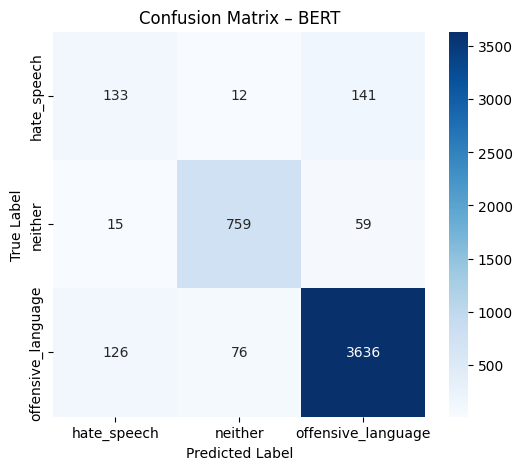

In [15]:
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix – BERT")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Conclusion

The BERT model demonstrates improved performance compared to traditional
machine learning approaches by capturing contextual information in text.

This makes transformer-based models particularly effective for detecting
subtle or implicit forms of hate speech.